In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

orders = pd.read_csv("datasets/processed_orders.csv")

print("Dataset Loaded Successfully")

orders.head()

Dataset Loaded Successfully


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Sales per Unit,Cost per Unit,Distance Category,High Value Order,Route ID,Shipping Rate ($/km),Estimated Shipping Cost,Delivery Efficiency Score,Factory Order Count,Factory Workload
0,1,ORD00001,2025-02-07,2025-02-08,1,CUST9313,USA,Houston,TX,38140,...,2.69,1.74,2,1,Sugar Shack_South,1.1,326.7,297.0,1676,0
1,2,ORD00002,2025-05-04,2025-05-05,1,CUST3028,USA,Chicago,IL,39260,...,3.56,2.88,2,0,Lot's O' Nuts_Central,1.1,424.6,386.0,996,0
2,3,ORD00003,2025-04-24,2025-04-25,1,CUST7867,USA,New York,NY,28907,...,3.70,2.89,2,0,Secret Factory_East,1.1,333.3,303.0,977,2
3,4,ORD00004,2025-10-25,2025-10-29,2,CUST2028,USA,Los Angeles,CA,83972,...,3.72,2.43,1,0,Lot's O' Nuts_West,0.6,313.2,130.5,996,0
4,5,ORD00005,2025-08-07,2025-08-12,1,CUST6924,USA,Houston,TX,49291,...,4.67,2.66,3,1,Sugar Shack_South,1.1,2504.7,455.4,1676,0


In [3]:
features = [
    'Distance (km)',
    'Sales',
    'Units',
    'Cost',
    'Estimated Shipping Cost',
    'Ship Mode',
    'Division',
    'Region',
    'Factory'
]

target = 'Lead Time'

In [4]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    'Ship Mode',
    'Division',
    'Region',
    'Factory'
]

for column in categorical_columns:

    encoder = LabelEncoder()

    orders[column] = encoder.fit_transform(orders[column])

    label_encoders[column] = encoder

In [5]:
X = orders[features]

y = orders[target]

print(X.shape)
print(y.shape)

(5000, 9)
(5000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (4000, 9)
Testing Shape : (1000, 9)


In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [8]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression")

print("MAE :", lr_mae)

print("RMSE :", lr_rmse)

print("R2 :", lr_r2)

Linear Regression
MAE : 0.38913062537345217
RMSE : 0.49083665235236146
R2 : 0.9236330263513332


In [10]:
# ==========================================================
# Random Forest Regressor
# ==========================================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [11]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regressor")
print("-"*40)
print("MAE :", round(rf_mae,3))
print("RMSE:", round(rf_rmse,3))
print("R²  :", round(rf_r2,3))

Random Forest Regressor
----------------------------------------
MAE : 0.005
RMSE: 0.052
R²  : 0.999


In [12]:
# ==========================================================
# Gradient Boosting Regressor
# ==========================================================

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_predictions = gbr.predict(X_test)

In [13]:
gbr_mae = mean_absolute_error(y_test, gbr_predictions)

gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_predictions))

gbr_r2 = r2_score(y_test, gbr_predictions)

print("Gradient Boosting Regressor")
print("-"*40)
print("MAE :", round(gbr_mae,3))
print("RMSE:", round(gbr_rmse,3))
print("R²  :", round(gbr_r2,3))

Gradient Boosting Regressor
----------------------------------------
MAE : 0.009
RMSE: 0.041
R²  : 0.999


In [14]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gbr_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gbr_rmse
    ],
    "R² Score": [
        lr_r2,
        rf_r2,
        gbr_r2
    ]
})

comparison = comparison.sort_values(
    by="R² Score",
    ascending=False
)

comparison

,Model,MAE,RMSE,R² Score
2,Gradient Boosting,0.009289,0.040942,0.999469
1,Random Forest,0.004890,0.052107,0.999139
0,Linear Regression,0.389131,0.490837,0.923633


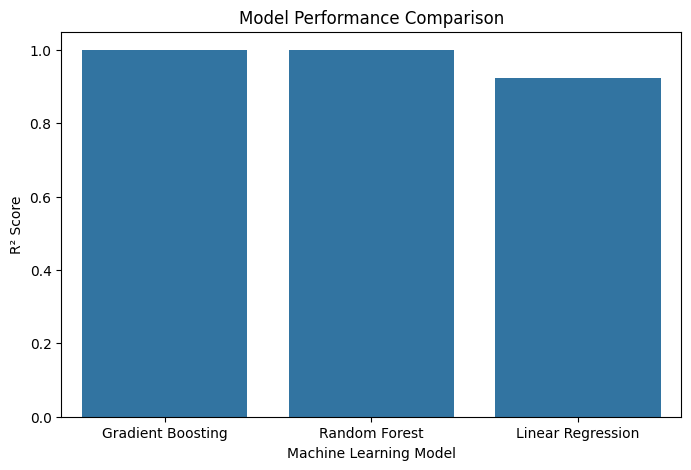

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R² Score"
)

plt.title("Model Performance Comparison")
plt.ylabel("R² Score")
plt.xlabel("Machine Learning Model")

plt.show()

In [16]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Distance (km),0.586643
5,Ship Mode,0.385906
4,Estimated Shipping Cost,0.027449
3,Cost,0.000002
1,Sales,0.000000
2,Units,0.000000
6,Division,0.000000
7,Region,0.000000
8,Factory,0.000000


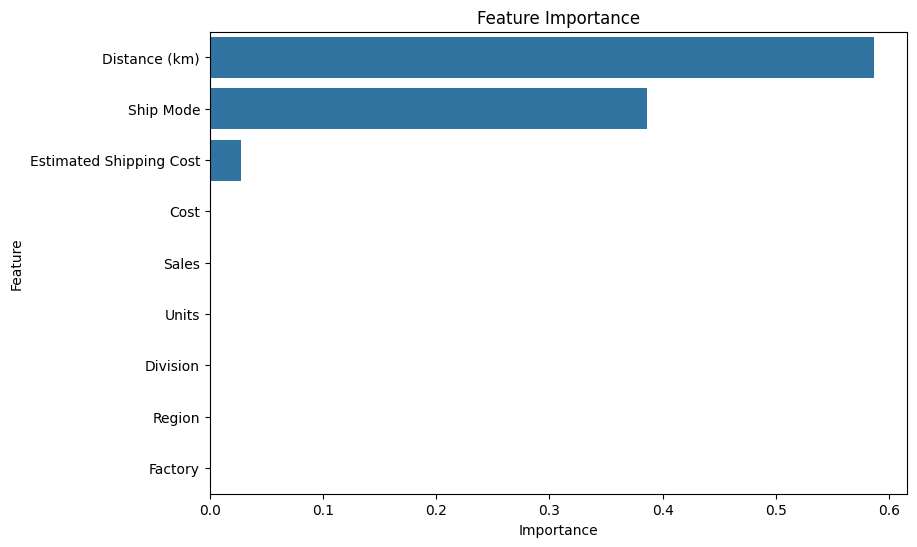

In [17]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [19]:
# ==========================================================
# Save Best Model
# ==========================================================

best_model = None
best_model_name = ""

if comparison.iloc[0]["Model"] == "Random Forest":
    best_model = rf
    best_model_name = "Random Forest"

elif comparison.iloc[0]["Model"] == "Gradient Boosting":
    best_model = gbr
    best_model_name = "Gradient Boosting"

else:
    best_model = lr
    best_model_name = "Linear Regression"

joblib.dump(
    best_model,
    "best_lead_time_model.pkl"
)

print(f"{best_model_name} saved successfully!")

Gradient Boosting saved successfully!
